In [59]:
import os

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_PROJECT"] = "learning"

### What is the Agent Executor?

When we talk about agents, a significant part of an "agent" is simple code logic, iteratively rerunning LLM calls and processing their output. The exact logic varies significantly, but one well-known example is the ReAct agent.

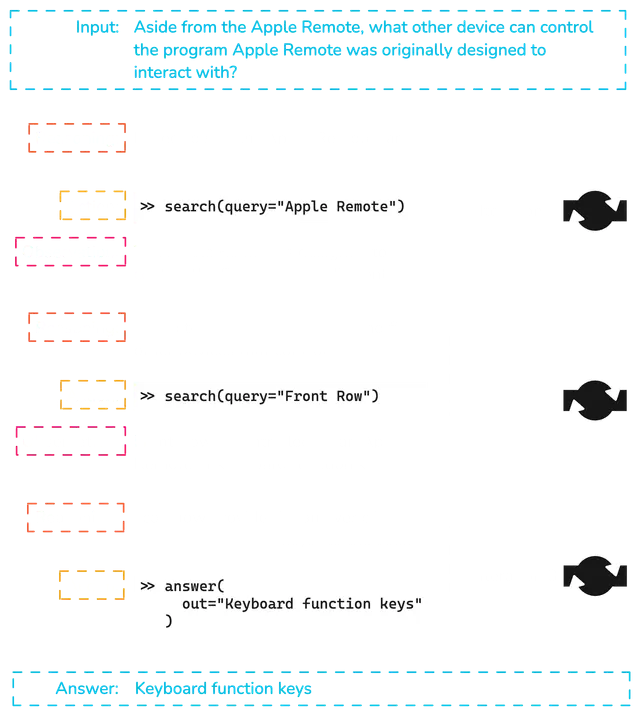

Reason + Action (ReAct) agents use iterative reasoning and action steps to incorporate chain-of-thought and tool-use into their execution. During the reasoning step, the LLM generates the steps to take to answer the query. Next, the LLM generates the action input, which our code logic parses into a tool call.

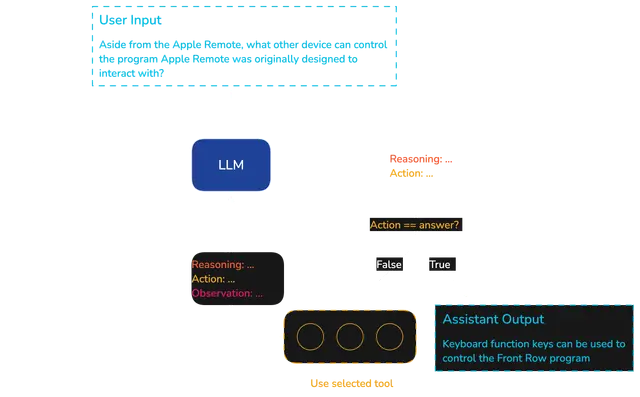

In [60]:
from langchain_core.tools import tool

@tool
def add(x: float, y: float) -> float:
    """Add 'x' and 'y'."""
    return x + y

# Define the multiply tool
@tool
def multiply(x: float, y: float) -> float:
    """Multiply 'x' and 'y'."""
    return x * y

# Define the exponentiate tool
@tool
def exponentiate(x: float, y: float) -> float:
    """Raise 'x' to the power of 'y'."""
    return x ** y

@tool
def subtract(x: float, y: float) -> float:
    """Subtract 'x' from 'y'."""
    return y - x

In [61]:
add

StructuredTool(name='add', description="Add 'x' and 'y'.", args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x7327641465c0>)

In [62]:
print(f"{add.name=}\n{add.description=}")

add.name='add'
add.description="Add 'x' and 'y'."


In [63]:
add.args_schema.model_json_schema()

{'description': "Add 'x' and 'y'.",
 'properties': {'x': {'title': 'X', 'type': 'number'},
  'y': {'title': 'Y', 'type': 'number'}},
 'required': ['x', 'y'],
 'title': 'add',
 'type': 'object'}

In [64]:
import json

llm_output_string = "{\"x\": 5, \"y\": 2}"  # this is the output from the LLM
llm_output_dict = json.loads(llm_output_string)  # load as dictionary
llm_output_dict

{'x': 5, 'y': 2}

In [65]:

exponentiate.func(**llm_output_dict)

25

### Creating an Agent

In [66]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "You're a helpful assistant. When answering a user's question "
        "you should first use one of the tools provided. After using a "
        "tool the tool output will be provided in the "
        "'scratchpad' below. If you have an answer in the "
        "scratchpad you should not use any more tools and "
        "instead answer directly to the user."
    )),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

In [67]:
from langchain_openai import ChatOpenAI
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv
load_dotenv()

creative_llm = ChatOpenAI(
    model="gpt-5-mini",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
    temperature=0.9
)

llm = ChatOpenAI(
    model="gpt-3.5-turbo",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
    temperature=0.0
)
llm1 = ChatOpenRouter(
    model = "openai/gpt-oss-20b"
)
llm2 = ChatOpenRouter(
    model = "nvidia/nemotron-nano-9b-v2"
)

In [68]:
from langchain_core.runnables.base import RunnableSerializable

tools =  [add, subtract, multiply, exponentiate]

agent : RunnableSerializable = (
    {
        "input": lambda x:x["input"],
        "chat_history": lambda x: x["chat_history"],
        "agent_scratchpad": lambda x:x.get("agent_scratchpad", [])
    }
    | prompt
    | llm.bind_tools(tools, tool_choice="any")
)

In [69]:
tool_call = agent.invoke({"input" : "What is 10 + 10", "chat_history": []})
tool_call

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 197, 'total_tokens': 215, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DgpgZqlmKyB4yJ1ScfqR8OtqXRMtj', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e3aac-39eb-7c40-bb11-81da3a00bc80-0', tool_calls=[{'name': 'add', 'args': {'x': 10, 'y': 10}, 'id': 'call_6wxYTr5LDEsSrnPafwVzkW2j', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 197, 'output_tokens': 18, 'total_tokens': 215, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [70]:

tool_call.tool_calls

[{'name': 'add',
  'args': {'x': 10, 'y': 10},
  'id': 'call_6wxYTr5LDEsSrnPafwVzkW2j',
  'type': 'tool_call'}]



From here, we have the tool name that our LLM wants to use and the args that it wants to pass to that tool. We can see that the tool add is being used with the arguments x=10 and y=10. The agent.invoke method has not executed the tool function; we need to write that part of the agent code ourselves.

Executing the tool code requires two steps:

    Map the tool name to the tool function.

    Execute the tool function with the generated args.



In [71]:
# create tool name to function mapping
name2tool = {tool.name: tool.func for tool in tools}

In [72]:
name2tool

{'add': <function __main__.add(x: float, y: float) -> float>,
 'subtract': <function __main__.subtract(x: float, y: float) -> float>,
 'multiply': <function __main__.multiply(x: float, y: float) -> float>,
 'exponentiate': <function __main__.exponentiate(x: float, y: float) -> float>}

In [73]:
tool_exec_content = name2tool[tool_call.tool_calls[0]["name"]](
    **tool_call.tool_calls[0]["args"]
)
tool_exec_content

20

In [74]:
from langchain_core.messages import ToolMessage

tool_exec = ToolMessage(
    content=f"The {tool_call.tool_calls[0]['name']} tool returned {tool_exec_content}",
    tool_call_id=tool_call.tool_calls[0]["id"]
)

out = agent.invoke({
    "input": "What is 10 + 10",
    "chat_history": [],
    "agent_scratchpad": [tool_call, tool_exec]
})
out

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 227, 'total_tokens': 245, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DgpgafglmIZOqjB36gMxNMPZ4hXfH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e3aac-412c-7873-8746-c808277c9836-0', tool_calls=[{'name': 'add', 'args': {'x': 10, 'y': 10}, 'id': 'call_ZExsZREmLi21xyf6Ixb6r9m9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 227, 'output_tokens': 18, 'total_tokens': 245, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

Despite having the answer in our agent_scratchpad, the LLM still tries to use the tool again. This behaviour happens because we bonded the tools to the LLM with tool_choice="any". When we set tool_choice to "any" or "required", we tell the LLM that it MUST use a tool, i.e., it cannot provide a final answer.

There's two options to fix this:

    Set tool_choice="auto" to tell the LLM that it can choose to use a tool or provide a final answer.

    Create a final_answer tool - we'll explain this shortly.


- Option 1

In [75]:
agent: RunnableSerializable = (
    {
        "input": lambda x: x["input"],
        "chat_history": lambda x: x["chat_history"],
        "agent_scratchpad": lambda x: x.get("agent_scratchpad", [])
    }
    | prompt
    | llm.bind_tools(tools, tool_choice="auto")
)

In [76]:


tool_call = agent.invoke({"input": "What is 10 + 10", "chat_history": []})
tool_call



AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 197, 'total_tokens': 215, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DgpgcxQVTXAf9gsldWNEthmeciH3b', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e3aac-49aa-7662-a77b-c98e1ee54dd8-0', tool_calls=[{'name': 'add', 'args': {'x': 10, 'y': 10}, 'id': 'call_7jdywLWMDGBwHxAI0dVtRnfy', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 197, 'output_tokens': 18, 'total_tokens': 215, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [77]:
tool_output = name2tool[tool_call.tool_calls[0]["name"]](
    **tool_call.tool_calls[0]["args"]
)

tool_exec = ToolMessage(
    content=f"The {tool_call.tool_calls[0]['name']} tool returned {tool_output}",
    tool_call_id=tool_call.tool_calls[0]["id"]
)

out = agent.invoke({
    "input": "What is 10 + 10",
    "chat_history": [],
    "agent_scratchpad": [tool_call, tool_exec]
})
out

AIMessage(content='10 + 10 equals 20.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 227, 'total_tokens': 237, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-Dgpge36UITWx7Y7i9rr7PQU3wqK8Z', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3aac-5142-7cd1-b341-2ef5f24ee5c4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 227, 'output_tokens': 10, 'total_tokens': 237, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})



We now have the final answer in the content field! This method is perfectly functional; however, we recommend option 2 as it provides more control over the agent's output.

There are several reasons that option 2 can provide more control, those are:

    It removes the possibility of an agent using the direct content field when it is not appropriate; for example, some LLMs (particularly smaller ones) may try to use the content field when using a tool.

    We can enforce a specific structured output in our answers. Structured outputs are handy when we require particular fields for downstream code or multi-part answers. For example, a RAG agent may return a natural language answer and a list of sources used to generate that answer.

To implement option 2, we must create a final_answer tool. We will add a tools_used field to give our output some structure—in a real-world use case, we probably wouldn't want to generate this field, but it's useful for our example here.


In [78]:
@tool
def final_answer(answer: str, tools_used : list[str]) -> str:
    """ Use this tool to provide a finla answer to the user.
    The answer should be in natural language as this will be provided to 
    the user directly. The tools_used must includea list of tool names that
    were used within the `scratchpad`. """
    return {"answer": answer, "tools_used": tools_used}
    

In [79]:


tools = [final_answer, add, subtract, multiply, exponentiate]

# we need to update our name2tool mapping too
name2tool = {tool.name: tool.func for tool in tools}

agent: RunnableSerializable = (
    {
        "input": lambda x: x["input"],
        "chat_history": lambda x: x["chat_history"],
        "agent_scratchpad": lambda x: x.get("agent_scratchpad", [])
    }
    | prompt
    | llm.bind_tools(tools, tool_choice="any")  # we're forcing tool use again
)



In [80]:


tool_call = agent.invoke({"input": "What is 10 + 10", "chat_history": []})
tool_call.tool_calls



[{'name': 'add',
  'args': {'x': 10, 'y': 10},
  'id': 'call_ir3eWg0xrRteZFEvdXiX3GxV',
  'type': 'tool_call'}]

In [81]:


tool_out = name2tool[tool_call.tool_calls[0]["name"]](
    **tool_call.tool_calls[0]["args"]
)

tool_exec = ToolMessage(
    content=f"The {tool_call.tool_calls[0]['name']} tool returned {tool_out}",
    tool_call_id=tool_call.tool_calls[0]["id"]
)

out = agent.invoke({
    "input": "What is 10 + 10",
    "chat_history": [],
    "agent_scratchpad": [tool_call, tool_exec]
})
out



AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 300, 'total_tokens': 328, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DgpghHMiZy6UGcjyN2zB5GM9JumnT', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e3aac-5d6b-7d10-b075-c98c6a202a27-0', tool_calls=[{'name': 'final_answer', 'args': {'answer': '10 + 10 equals 20.', 'tools_used': ['functions.add']}, 'id': 'call_yPFaLRshzl6CM7lbSTbIjnZF', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 300, 'output_tokens': 28, 'total_tokens': 328, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_tok

In [82]:


out.tool_calls



[{'name': 'final_answer',
  'args': {'answer': '10 + 10 equals 20.', 'tools_used': ['functions.add']},
  'id': 'call_yPFaLRshzl6CM7lbSTbIjnZF',
  'type': 'tool_call'}]

In [83]:


out.tool_calls[0]["args"]



{'answer': '10 + 10 equals 20.', 'tools_used': ['functions.add']}

### Building a Custom Agent Execution Loop

In [84]:
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage


class CustomAgentExecutor:
    chat_history: list[BaseMessage]

    def __init__(self, max_iterations: int = 3):
        self.chat_history = []
        self.max_iterations = max_iterations
        self.agent: RunnableSerializable = (
            {
                "input": lambda x: x["input"],
                "chat_history": lambda x: x["chat_history"],
                "agent_scratchpad": lambda x: x.get("agent_scratchpad", [])
            }
            | prompt
            | llm.bind_tools(tools, tool_choice="any")  # we're forcing tool use again
        )

    def invoke(self, input: str) -> dict:
        # invoke the agent but we do this iteratively in a loop until
        # reaching a final answer
        count = 0
        agent_scratchpad = []
        while count < self.max_iterations:
            # invoke a step for the agent to generate a tool call
            tool_call = self.agent.invoke({
                "input": input,
                "chat_history": self.chat_history,
                "agent_scratchpad": agent_scratchpad
            })
            # add initial tool call to scratchpad
            agent_scratchpad.append(tool_call)
            # otherwise we execute the tool and add it's output to the agent scratchpad
            tool_name = tool_call.tool_calls[0]["name"]
            tool_args = tool_call.tool_calls[0]["args"]
            tool_call_id = tool_call.tool_calls[0]["id"]
            tool_out = name2tool[tool_name](**tool_args)
            # add the tool output to the agent scratchpad
            tool_exec = ToolMessage(
                content=f"{tool_out}",
                tool_call_id=tool_call_id
            )
            agent_scratchpad.append(tool_exec)
            # add a print so we can see intermediate steps
            print(f"{count}: {tool_name}({tool_args})")
            count += 1
            # if the tool call is the final answer tool, we stop
            if tool_name == "final_answer":
                break
        # add the final output to the chat history
        final_answer = tool_out["answer"]
        self.chat_history.extend([
            HumanMessage(content=input),
            AIMessage(content=final_answer)
        ])
        # return the final answer in dict form
        return json.dumps(tool_out)

In [85]:
agent_executor = CustomAgentExecutor()

In [86]:
agent_executor.invoke(input="What is 10 + 10")

0: add({'x': 10, 'y': 10})
1: final_answer({'answer': '10 + 10 equals 20.', 'tools_used': ['functions.add']})


'{"answer": "10 + 10 equals 20.", "tools_used": ["functions.add"]}'